# Exploratory Data Analysis

This notebook explores the statistical and temporal structure of the cleaned
SPY market data.

The analysis focuses on price movements, returns, volatility, distributions,
and temporal dependence, with particular attention to the five-day volatility
prediction problem.

The purpose of this notebook is to establish the conventional statistical
properties of the dataset before constructing predictive features and models.

Topological Data Analysis (TDA) is treated as a complementary component of
the exploratory analysis and is developed separately in
`04_tda.ipynb`. There, we investigate whether the temporal geometry of the
market data contains structural information that is not captured by
conventional statistical analysis.

## 1. Imports and Load Data

### 1.1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

### 1.2: Set Project Path

In [2]:
# Define project directories

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

CLEAN_DATA_FILE = PROCESSED_DATA_DIR / "spy_daily_clean.csv"

### 1.3: Load The Cleaned Data

In [3]:
# Load the cleaned SPY data

spy_data = pd.read_csv(
    CLEAN_DATA_FILE,
    index_col=0,
    parse_dates=True
)

spy_data.head()

,Close,High,Low,Open,Volume
2010-01-04,84.578491,84.623268,83.220220,83.862041,118944600
2010-01-05,84.802376,84.839693,84.220261,84.526247,111579900
2010-01-06,84.862091,85.071055,84.653127,84.720292,116074400
2010-01-07,85.220306,85.324788,84.466539,84.705356,131091100
2010-01-08,85.503906,85.541224,84.824774,84.996420,126402800


In [4]:
spy_data.shape

(4191, 5)

In [5]:
spy_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

## 2. Descriptive Statistics
We begin the exploratory analysis by examining summary statistics for the
SPY market variables. These statistics provide a first view of the scale and 
variability of the price and volume data before we construct returns, volatility measures,
and other derived quantities.

### 2.1: Summary Statistics

In [6]:
spy_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Close,4191.0,2.852252e+02,1.756623e+02,7.695058e+01,1.498391e+02,2.357051e+02,3.970325e+02,7.778800e+02
High,4191.0,2.866867e+02,1.764943e+02,7.786917e+01,1.505601e+02,2.378689e+02,3.992022e+02,7.793700e+02
Low,4191.0,2.835228e+02,1.746823e+02,7.614496e+01,1.493003e+02,2.343038e+02,3.942901e+02,7.754300e+02
Open,4191.0,2.851729e+02,1.756365e+02,7.763576e+01,1.498472e+02,2.360075e+02,3.968919e+02,7.785400e+02
Volume,4191.0,1.075912e+08,6.735463e+07,2.027000e+07,6.414270e+07,8.782090e+07,1.304040e+08,7.178287e+08


### 2.2: Data Coverage
We verify the number of observations and the historical period represented
in the cleaned dataset.

In [7]:
# Check data coverage

print(f"Number of observations: {len(spy_data):,}")
print(f"First observation: {spy_data.index.min().date()}")
print(f"Last observation: {spy_data.index.max().date()}")

Number of observations: 4,191
First observation: 2010-01-04
Last observation: 2026-09-01


## 3. Returns Analysis

Price levels are generally non-stationary over long periods, making them
less suitable for studying the statistical dynamics of market movements. 
We therefore transform the adjusted closing prices into daily logarithmic
returns:

$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right),
$$

where \(P_t\) denotes the adjusted closing price on day \(t\).
Log returns are convenient for volatility analysis and will also provide
the primary time series used in the subsequent topological analysis.

### 3.1: Calculate Daily Log Return

In [8]:
# Calculate daily log returns

spy_data["log_return"] = np.log(
    spy_data["Close"] / spy_data["Close"].shift(1)
)

spy_data.head()

,Close,High,Low,Open,Volume,log_return
2010-01-04,84.578491,84.623268,83.220220,83.862041,118944600,NaN
2010-01-05,84.802376,84.839693,84.220261,84.526247,111579900,0.002644
2010-01-06,84.862091,85.071055,84.653127,84.720292,116074400,0.000704
2010-01-07,85.220306,85.324788,84.466539,84.705356,131091100,0.004212
2010-01-08,85.503906,85.541224,84.824774,84.996420,126402800,0.003322


In [9]:
# Check the resulting returns

print(f"Missing log returns: {spy_data['log_return'].isna().sum()}")
print(f"Mean daily log return: {spy_data['log_return'].mean():.6f}")
print(f"Standard deviation: {spy_data['log_return'].std():.6f}")

Missing log returns: 1
Mean daily log return: 0.000525
Standard deviation: 0.010777


### 3.2: Distribution of Daily Returns
We examine the distribution of daily log returns to assess its central
tendency, dispersion, and the presence of unusually large movements.
Financial returns are typically characterized by heavy tails, meaning that
extreme observations occur more frequently than would be expected under a
simple Gaussian model.

In [10]:
# Summary statistics for daily log returns

spy_data["log_return"].describe()

count    4190.000000
mean        0.000525
std         0.010777
min        -0.115887
25%        -0.003711
50%         0.000704
75%         0.005774
max         0.099863
Name: log_return, dtype: float64

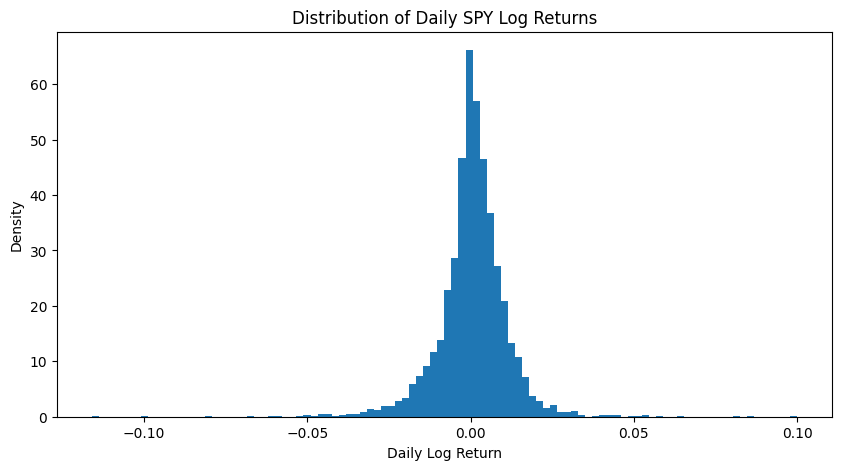

In [11]:
# Plot the distribution of daily log returns

plt.figure(figsize=(10, 5))

plt.hist(
    spy_data["log_return"].dropna(),
    bins=100,
    density=True
)

plt.xlabel("Daily Log Return")
plt.ylabel("Density")
plt.title("Distribution of Daily SPY Log Returns")

plt.show()

**Observation:**
The descriptive statistics and histogram provide evidence about the statistical characteristics of the daily SPY log returns.

- The dataset contains **4,190 daily observations**. The mean daily log return is approximately **0.000525 (0.0525%)**, while the median is **0.000704 (0.0704%)**. This indicates that the typical daily return is close to zero, with a small positive average return over the sample period.

- The standard deviation is approximately **0.010777 (1.08%)**, indicating that daily returns generally fluctuate around the mean by about 1% and providing an initial measure of daily market volatility.

- The minimum and maximum returns are approximately **−11.56%** and **+9.99%**, respectively. These relatively large movements indicate the presence of **extreme daily price changes**.

- The histogram is highly concentrated around zero but has **long tails on both sides**. This suggests that most daily returns are relatively small, while unusually large positive and negative returns occur occasionally.

- The distribution therefore appears to exhibit **fat/heavy tails**, meaning extreme returns occur more frequently than would typically be expected under a simple normal (Gaussian) distribution.

Overall, the analysis suggests that SPY daily log returns are centered close to zero, exhibit moderate daily variability, and contain occasional extreme observations. The presence of heavy tails is an important characteristic to consider in subsequent **volatility and topological analysis**.


## 4. Volatility Analysis

The prediction target in this project is based on volatility over a
five-trading-day horizon.
Daily returns provide the fundamental building blocks for realized
volatility. We therefore construct five-day realized volatility directly
from the daily log returns.

For day \(t\), define the forward five-day realized volatility as

$$
RV_{t,t+5}
=
\sqrt{
\frac{1}{5}
\sum_{k=1}^{5} r_{t+k}^{\,2}
},
$$

where \(r_t\) denotes the daily log return.

This is a forward-looking quantity and will ultimately be used to define
the prediction target. It must therefore be constructed carefully to avoid
using future information as a predictor.

### 4.1: Five-Day Forward Realized Volatility

In [12]:
# Calculate five-day forward realized volatility

WINDOW = 5

future_squared_returns = (
    spy_data["log_return"]
    .pow(2)
    .shift(-1)
)

spy_data["future_5d_rv"] = np.sqrt(
    future_squared_returns
    .rolling(WINDOW)
    .mean()
    .shift(-(WINDOW - 1))
)

spy_data[["log_return", "future_5d_rv"]].head(10)

,log_return,future_5d_rv
2010-01-04,NaN,0.002765
2010-01-05,0.002644,0.004879
2010-01-06,0.000704,0.006153
2010-01-07,0.004212,0.005980
2010-01-08,0.003322,0.007684
2010-01-11,0.001396,0.009460
2010-01-12,-0.009370,0.009634
2010-01-13,0.008411,0.012413
2010-01-14,0.002701,0.015946
2010-01-15,-0.011288,0.015298


### 4.2: Current Rolling Volatility

To compare future realized volatility with the volatility currently observed
at time \(t\), we construct a backward-looking estimate of current volatility.

We use a 20-trading-day rolling realized volatility:

$$
\sigma_t^{(20)}
=
\sqrt{
\frac{1}{20}
\sum_{j=0}^{19} r_{t-j}^{\,2}
}.
$$

Unlike the forward five-day realized volatility, this quantity uses only
information available on or before day \(t\).

This provides a public-data analogue of the current volatility estimate used
in the internship project.

In [13]:
# Calculate 20-day backward-looking realized volatility

CURRENT_VOL_WINDOW = 20

spy_data["current_20d_vol"] = np.sqrt(
    spy_data["log_return"]
    .pow(2)
    .rolling(CURRENT_VOL_WINDOW)
    .mean()
)

spy_data[["log_return", "current_20d_vol", "future_5d_rv"]].head(25)

,log_return,current_20d_vol,future_5d_rv
2010-01-04,NaN,NaN,0.002765
2010-01-05,0.002644,NaN,0.004879
2010-01-06,0.000704,NaN,0.006153
2010-01-07,0.004212,NaN,0.005980
2010-01-08,0.003322,NaN,0.007684
2010-01-11,0.001396,NaN,0.009460
2010-01-12,-0.009370,NaN,0.009634
2010-01-13,0.008411,NaN,0.012413
2010-01-14,0.002701,NaN,0.015946
2010-01-15,-0.011288,NaN,0.015298


In [14]:
# Check the number of missing observations

print(
    f"Missing current 20-day volatility: "
    f"{spy_data['current_20d_vol'].isna().sum()}"
)

print(
    f"Missing future 5-day realized volatility: "
    f"{spy_data['future_5d_rv'].isna().sum()}"
)

Missing current 20-day volatility: 20
Missing future 5-day realized volatility: 5


### 4.3: Future Volatility vs. Current Volatility
The central quantity in the volatility prediction problem is the relationship
between volatility observed at time \(t\) and volatility realized over the
following five trading days. Roughly we ask: "Does the volatility observed over the past month contain information about the volatility that will occur over the next week?"

We compare the forward five-day realized volatility,

$$
RV_{t,t+5},
$$

with the current 20-day backward-looking volatility estimate,

$$
\sigma_t^{(20)}.
$$

A useful way to express this comparison is through their logarithmic ratio:

$$
L_t =
\log\left(
\frac{RV_{t,t+5}}{\sigma_t^{(20)}}
\right).
$$

Positive values indicate that future realized volatility exceeded the
current volatility estimate, while negative values indicate that future
realized volatility was lower.



In [15]:
# Compare future realized volatility with current volatility

spy_data["log_vol_ratio"] = np.log(
    spy_data["future_5d_rv"] / spy_data["current_20d_vol"]
)

spy_data[
    ["current_20d_vol", "future_5d_rv", "log_vol_ratio"]
].dropna().head(10)

,current_20d_vol,future_5d_rv,log_vol_ratio
2010-02-02,0.010433,0.015624,0.403763
2010-02-03,0.010476,0.015488,0.390931
2010-02-04,0.012605,0.008060,-0.447158
2010-02-05,0.012578,0.008016,-0.450557
2010-02-08,0.012660,0.010124,-0.223520
2010-02-09,0.012960,0.008707,-0.397793
2010-02-10,0.012797,0.009052,-0.346196
2010-02-11,0.012871,0.007818,-0.498495
2010-02-12,0.012858,0.007810,-0.498580
2010-02-16,0.013082,0.006489,-0.701174


Inspect its distribution:

In [16]:
# Summary statistics of the log volatility ratio

spy_data["log_vol_ratio"].describe()

count    4166.000000
mean       -0.125770
std         0.520109
min        -2.251823
25%        -0.458419
50%        -0.110625
75%         0.189944
max         1.700821
Name: log_vol_ratio, dtype: float64

now, visualize it:

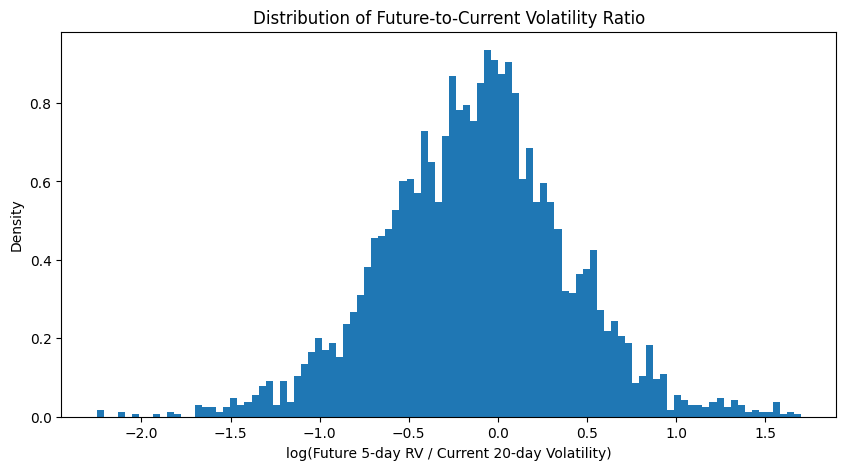

In [17]:
# Plot the distribution of the log volatility ratio

plt.figure(figsize=(10, 5))

plt.hist(
    spy_data["log_vol_ratio"].dropna(),
    bins=100,
    density=True
)

plt.xlabel("log(Future 5-day RV / Current 20-day Volatility)")
plt.ylabel("Density")
plt.title("Distribution of Future-to-Current Volatility Ratio")

plt.show()

**Observation:** This is very informative, and it confirms that we should not blindly import the internship threshold \(0.5\).

Our distribution has:

$$ \text{mean}=-0.1258,\qquad \text{median}=-0.1106,\qquad \text{std}=0.5210. $$

So, on average, the five-day future volatility is somewhat lower than the preceding 20-day volatility estimate. The distribution is also fairly broad, with substantial observations on both sides of zero.

Recall

$$ L_t=\log\left(\frac{RV_{t,t+5}}{\sigma_t^{(20)}}\right). $$

Therefore:

\(L_t>0\): future volatility is higher than current volatility.
\(L_t=0\): they are equal.
\(L_t<0\): future volatility is lower.

The internship threshold \(0.5\) would mean

$$ RV_{t,t+5}>e^{0.5}\sigma_t \approx1.65\sigma_t, $$

which is a quite strong volatility increase. That may have made sense for the proprietary specific_vol, but we shouldn't assume it makes sense here.

Let's empirically examine candidate thresholds

### 4.4: Choosing a Volatility-Increase Threshold

The internship project classified an observation as a positive volatility
event when

$$
\log(RV_{t,t+5}/\sigma_t) > 0.5.
$$

Because the current volatility estimate in this project is constructed
differently, we do not assume that the same threshold is appropriate.

Instead, we examine several candidate thresholds and their resulting class
balance before defining the binary prediction target.

In [18]:
# Examine class proportions under different thresholds

valid_ratio = spy_data["log_vol_ratio"].dropna()

thresholds = [0.0, 0.1, 0.2, 0.3, 0.5]

for threshold in thresholds:
    positive_rate = (valid_ratio > threshold).mean()
    print(
        f"Threshold = {threshold:>3.1f} | "
        f"Positive class = {positive_rate:.2%}"
    )

Threshold = 0.0 | Positive class = 39.92%
Threshold = 0.1 | Positive class = 31.23%
Threshold = 0.2 | Positive class = 24.36%
Threshold = 0.3 | Positive class = 18.70%
Threshold = 0.5 | Positive class = 11.07%


In [19]:
# Examine quantiles of the log volatility ratio

valid_ratio.quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90]
)

0.10   -0.760269
0.25   -0.458419
0.50   -0.110625
0.75    0.189944
0.90    0.523881
Name: log_vol_ratio, dtype: float64

**Observation:** This is a very useful result. Now we have enough evidence to make an informed choice rather than importing the internship's \(0.5\) threshold. The key point is that 0.5 is around the 90th percentile. So using the internship threshold would turn our problem into detecting relatively rare extreme volatility increases. That's not necessarily wrong, but it would be a substantially different classification problem.

### 4.5: Defining a Volatility-Increase Event

For the predictive problem, we define a volatility-increase event based on
the logarithmic ratio between future five-day realized volatility and current
20-day volatility.

We use a threshold of \(0.2\):

$$
y_t =
\mathbf{1}
\left[
\log\left(
\frac{RV_{t,t+5}}{\sigma_t^{(20)}}
\right)>0.2
\right].
$$

Since

$$
e^{0.2}\approx1.22,
$$

a positive observation corresponds approximately to a future five-day
realized volatility that is at least 22% higher than the current volatility
estimate.

The threshold is chosen from the empirical distribution of the public SPY
dataset rather than directly importing the \(0.5\) threshold used in the
internship project. The latter would produce a much rarer event in this
dataset.

The binary target will be constructed formally in the later predictive
pipeline. Here we use the event definition only to understand its empirical
frequency.

In [20]:
# Examine the proposed volatility-increase event

TARGET_THRESHOLD = 0.2

positive_rate = (valid_ratio > TARGET_THRESHOLD).mean()

print(f"Threshold: {TARGET_THRESHOLD}")
print(f"Positive observations: {(valid_ratio > TARGET_THRESHOLD).sum():,}")
print(f"Negative observations: {(valid_ratio <= TARGET_THRESHOLD).sum():,}")
print(f"Positive class proportion: {positive_rate:.2%}")
print(f"Negative class proportion: {1 - positive_rate:.2%}")

Threshold: 0.2
Positive observations: 1,015
Negative observations: 3,151
Positive class proportion: 24.36%
Negative class proportion: 75.64%


## 5. Volatility Clustering

A well-known characteristic of financial returns is volatility clustering:
large absolute returns tend to be followed by other large absolute returns,
while periods of small absolute returns tend to persist as well.

We investigate this phenomenon before applying Topological Data Analysis.
This provides a conventional statistical description of temporal dependence
against which the later topological analysis can be compared.

### 5.1: Absolute Returns

The magnitude of returns provides a simple proxy for daily market activity.
We therefore examine the absolute daily log return,

$$
|r_t|.
$$

Persistent periods of large values indicate clusters of elevated market
activity.

In [21]:
# Calculate absolute returns

spy_data["abs_return"] = spy_data["log_return"].abs()

spy_data[["log_return", "abs_return"]].head()

,log_return,abs_return
2010-01-04,NaN,NaN
2010-01-05,0.002644,0.002644
2010-01-06,0.000704,0.000704
2010-01-07,0.004212,0.004212
2010-01-08,0.003322,0.003322


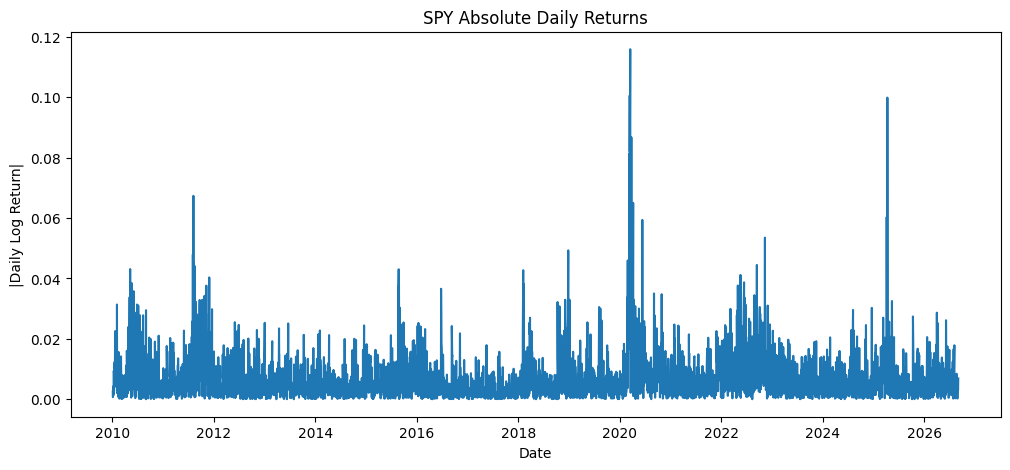

In [22]:
# Plot absolute returns over time

plt.figure(figsize=(12, 5))

plt.plot(
    spy_data.index,
    spy_data["abs_return"]
)

plt.xlabel("Date")
plt.ylabel("|Daily Log Return|")
plt.title("SPY Absolute Daily Returns")

plt.show()

### 5.2: Squared Returns

Squared returns place greater emphasis on extreme observations and provide
the basic quantity from which our realized volatility measures are constructed:

$$
r_t^2.
$$

Examining their temporal behaviour provides another view of volatility
clustering.

In [23]:
# Calculate squared returns

spy_data["squared_return"] = spy_data["log_return"].pow(2)

spy_data[["log_return", "squared_return"]].head()

,log_return,squared_return
2010-01-04,NaN,NaN
2010-01-05,0.002644,6.988439e-06
2010-01-06,0.000704,4.955061e-07
2010-01-07,0.004212,1.774316e-05
2010-01-08,0.003322,1.103780e-05


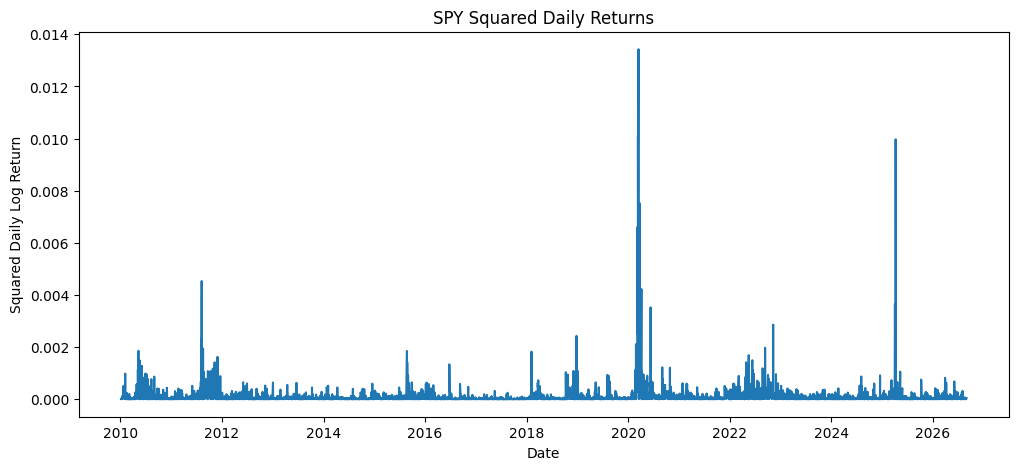

In [24]:
# Plot squared returns over time

plt.figure(figsize=(12, 5))

plt.plot(
    spy_data.index,
    spy_data["squared_return"]
)

plt.xlabel("Date")
plt.ylabel("Squared Daily Log Return")
plt.title("SPY Squared Daily Returns")

plt.show()

### 5.3: Autocorrelation of Return Magnitudes

If volatility clustering is present, the returns themselves may have little
linear autocorrelation while their magnitudes can exhibit substantial
autocorrelation.

We therefore examine the autocorrelation of absolute returns and squared
returns.

In [25]:
# Autocorrelation of return magnitudes

lags = [1, 5, 10, 20]

print("Absolute-return autocorrelation:")

for lag in lags:
    print(f"Lag {lag:>2}: {spy_data['abs_return'].autocorr(lag=lag):.4f}")

print("\nSquared-return autocorrelation:")

for lag in lags:
    print(f"Lag {lag:>2}: {spy_data['squared_return'].autocorr(lag=lag):.4f}")

Absolute-return autocorrelation:
Lag  1: 0.3065
Lag  5: 0.2867
Lag 10: 0.2528
Lag 20: 0.1614

Squared-return autocorrelation:
Lag  1: 0.4011
Lag  5: 0.2758
Lag 10: 0.2122
Lag 20: 0.0971


**Observation:** These results give us a strong conventional baseline before TDA. The absolute-return plot is particularly clear. There are persistent periods of elevated activity around major episodes, especially:
2011–12, 2015–16, 2018, 2020, 2022, and 2025

The squared-return plot makes the extreme events even more pronounced, with the COVID period standing out dramatically. More importantly, the autocorrelations quantify this.

That's substantial persistence. In particular, notice the contrast:

$$ \operatorname{Corr}(|r_t|,|r_{t-1}|)=0.3065 $$

and

$$ \operatorname{Corr}(r_t^2,r_{t-1}^2)=0.4011. $$

The squared-return autocorrelation remains positive even at lag 20. So volatility is clearly not behaving like independent daily noise.

This is precisely why our five-day volatility prediction problem is plausible: information about the recent volatility state contains information about the near future.

### 5.4: Five-Day Realized Volatility Through Time

We now examine the five-day realized volatility itself over the full
historical period.

This provides a direct view of the temporal structure relevant to the
five-day forecasting problem and allows us to identify periods of elevated
and subdued volatility.

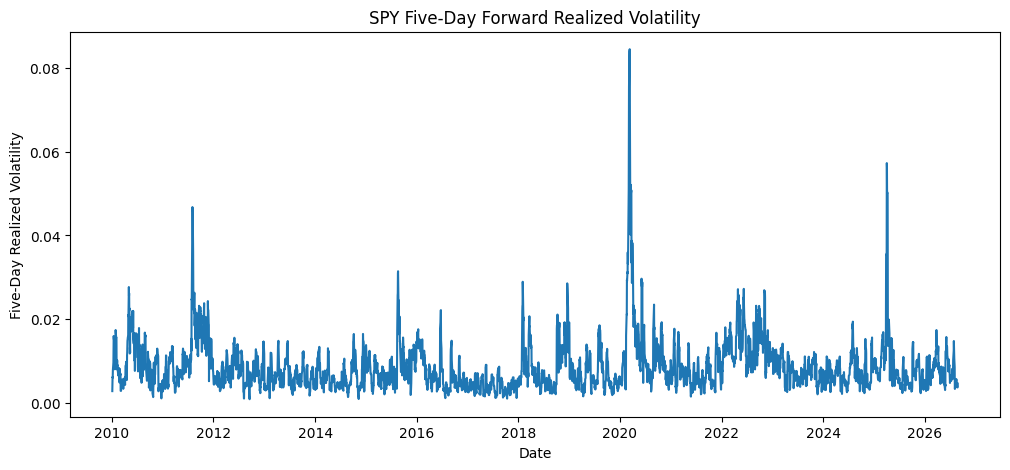

In [26]:
# Plot five-day forward realized volatility

plt.figure(figsize=(12, 5))

plt.plot(
    spy_data.index,
    spy_data["future_5d_rv"]
)

plt.xlabel("Date")
plt.ylabel("Five-Day Realized Volatility")
plt.title("SPY Five-Day Forward Realized Volatility")

plt.show()

#### Compare current and future volatility:
We do this because we want to know: "Can current volatility anticipate future volatility?"

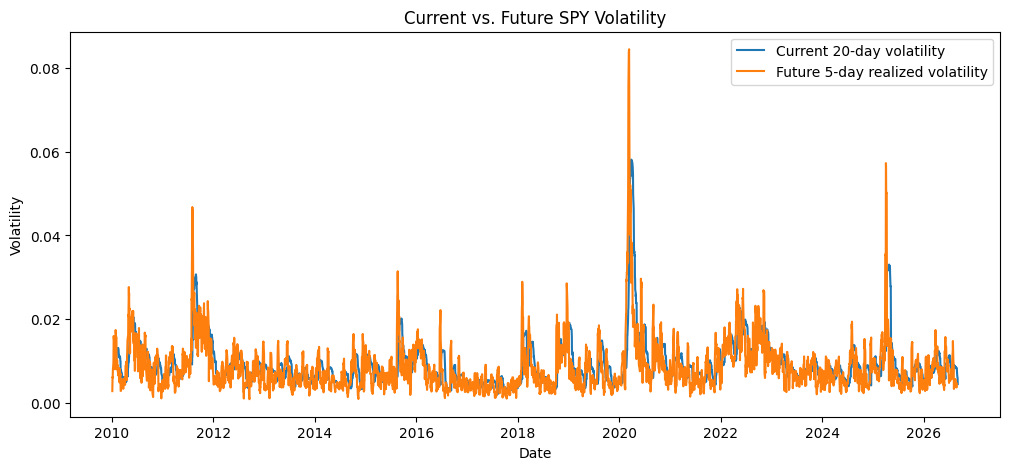

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(
    spy_data.index,
    spy_data["current_20d_vol"],
    label="Current 20-day volatility"
)

plt.plot(
    spy_data.index,
    spy_data["future_5d_rv"],
    label="Future 5-day realized volatility"
)

plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Current vs. Future SPY Volatility")

plt.legend()

plt.show()

**Observation:** The five-day forward realized volatility has pronounced volatility regimes. The most obvious is 2020, but there are also substantial episodes around 2011–12, 2015–16, 2018–19, 2022, and 2025.

More interestingly, the second plot shows that current 20-day volatility and future five-day volatility broadly move together, but they are not identical.

For example, around major volatility shocks, the orange future-volatility series can rise sharply before the blue current-volatility measure has fully responded. That's actually exactly the kind of forecasting situation we're interested in:

$$ \text{information available at }t \quad\longrightarrow\quad \text{volatility over }t+1,\ldots,t+5. $$

One caution: because future_5d_rv is a forward measure, we should never interpret the visual relationship as causal. It is a target-side quantity that we'll use for evaluation/training later.

### 5.5: Relationship Between Current and Future Volatility
We quantify the relationship between the current 20-day volatility estimate
and the subsequent five-day realized volatility.

A positive association would indicate that recent volatility contains
information about near-term future volatility. This provides a conventional
baseline against which additional features and the later topological analysis
can be evaluated.

In [29]:
# Correlation between current and future volatility

volatility_data = spy_data[
    ["current_20d_vol", "future_5d_rv"]
].dropna()

correlation = volatility_data["current_20d_vol"].corr(
    volatility_data["future_5d_rv"]
)

print(f"Correlation: {correlation:.4f}")

Correlation: 0.5936


Let's also calculate the correlation between the current volatility and our eventual event variable without actually creating the target column:

In [30]:
# Correlation between current volatility and the future-to-current ratio

ratio_data = spy_data[
    ["current_20d_vol", "log_vol_ratio"]
].dropna()

ratio_correlation = ratio_data["current_20d_vol"].corr(
    ratio_data["log_vol_ratio"]
)

print(
    f"Correlation between current volatility and "
    f"log volatility ratio: {ratio_correlation:.4f}"
)

Correlation between current volatility and log volatility ratio: -0.1993


**Observation:** Our two conventional results are enough to establish an important baseline:

$$ \operatorname{Corr}(\sigma_t^{(20)},RV_{t,t+5})=0.5936, $$

while

$$ \operatorname{Corr}\left( \sigma_t^{(20)}, \log\frac{RV_{t,t+5}}{\sigma_t^{(20)}} \right)=-0.1993. $$

The first says that current volatility has substantial association with future five-day volatility. The second is different: our target is a relative change in volatility, and its relationship with the current volatility level is weaker and negative.